In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from PIL import Image

import os
import torchvision.utils as vutils

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

base_original = '/content/drive/MyDrive/dataset_se_split'
base_masked = '/content/drive/MyDrive/dataset_se_masked'

class SpectrumPairDataset(Dataset):
    def __init__(self, original_dir, masked_dir, transform=None):
        self.original_dir = original_dir
        self.masked_dir   = masked_dir
        self.transform    = transform
        self.filenames    = sorted(
            [f for f in os.listdir(original_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        )

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        original = Image.open(os.path.join(self.original_dir, fname)).convert("RGB")
        masked   = Image.open(os.path.join(self.masked_dir,   fname)).convert("RGB")
        if self.transform:
            original = self.transform(original)
            masked   = self.transform(masked)
        return masked, original  # (input, target)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = SpectrumPairDataset(
    os.path.join(base_original, 'train'),
    os.path.join(base_masked,   'train'),
    transform=transform
)
val_dataset = SpectrumPairDataset(
    os.path.join(base_original, 'val'),
    os.path.join(base_masked,   'val'),
    transform=transform
)
test_dataset = SpectrumPairDataset(
    os.path.join(base_original, 'test'),
    os.path.join(base_masked,   'test'),
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False)

masked_batch, original_batch = next(iter(train_loader))
print(f"Masked shape:   {masked_batch.shape}")
print(f"Original shape: {original_batch.shape}")


Masked shape:   torch.Size([2, 3, 224, 224])
Original shape: torch.Size([2, 3, 224, 224])


In [ ]:
def knn_graph(x, k):
    B, C, N, _ = x.shape
    x_sq = x.squeeze(-1).permute(0, 2, 1)       # (B, N, C)
    dist = torch.cdist(x_sq, x_sq, p=2)         # (B, N, N)
    _, idx = dist.topk(k + 1, dim=-1, largest=False)
    return idx[:, :, 1:]                         # drop self-loop


class DynConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, k=9, dilation=1, act=None):
        super().__init__()
        self.k = k
        self.conv = nn.Conv2d(in_channels * 2, out_channels, 1)
        self.act = act

    def forward(self, x):
        B, C, N, _ = x.shape
        idx = knn_graph(x, self.k)

        x_flat = x.squeeze(-1).permute(0, 2, 1)
        idx_exp = idx.unsqueeze(-1).expand(-1, -1, -1, C)
        neighbors = torch.gather(
            x_flat.unsqueeze(2).expand(-1, -1, self.k, -1), 1, idx_exp
        )
        center = x_flat.unsqueeze(2).expand_as(neighbors)
        edge = torch.cat([center, neighbors - center], dim=-1)
        agg = edge.max(dim=2).values
        agg = agg.permute(0, 2, 1).unsqueeze(-1)

        out = self.conv(agg)
        if self.act is not None:
            out = self.act(out)
        return out


In [ ]:
class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        output = x.div(keep_prob) * random_tensor
        return output

In [ ]:
class GrapherModule(nn.Module):
    def __init__(self, in_channels, hidden_channels, k=9, dilation=1, drop_path=0.0):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 1),
            nn.BatchNorm2d(in_channels),
        )
        self.graph_conv = nn.Sequential(
            DynConv2d(in_channels, hidden_channels, k, dilation, act=None),
            nn.BatchNorm2d(hidden_channels),
            nn.GELU(),
        )
        self.fc2 = nn.Sequential(
            nn.Conv2d(hidden_channels, in_channels, 1),
            nn.BatchNorm2d(in_channels),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x
        x = self.fc1(x)
        x = self.graph_conv(x)
        x = self.fc2(x)
        x = self.drop_path(x) + shortcut
        return x


class FFNModule(nn.Module):
    def __init__(self, in_channels, hidden_channels, drop_path=0.0):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 1),
            nn.BatchNorm2d(hidden_channels),
            nn.GELU(),
        )
        self.fc2 = nn.Sequential(
            nn.Conv2d(hidden_channels, in_channels, 1),
            nn.BatchNorm2d(in_channels),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.drop_path(x) + shortcut
        return x

In [ ]:
class ViGBlock(nn.Module):
    def __init__(self, channels, k=9, dilation=1, drop_path=0.0):
        super().__init__()
        self.grapher = GrapherModule(channels, channels * 2, k, dilation, drop_path)
        self.ffn = FFNModule(channels, channels * 4, drop_path)

    def forward(self, x):
        x = self.grapher(x)
        x = self.ffn(x)
        return x

In [ ]:
class PatchEmbed(nn.Module):

    def __init__(self, in_channels, embed_dim, patch_size=8):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)
        B, E, n_h, n_w = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2).reshape(B, E, n_h, n_w)
        return x


class PatchUnembed(nn.Module):

    def __init__(self, embed_dim, out_channels, patch_size=8):
        super().__init__()
        self.proj = nn.ConvTranspose2d(embed_dim, out_channels,
                                       kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)

In [ ]:
import math
import torchvision.transforms as T

def generate_sparse_mask(H, W, observed_fraction=0.10, device="cpu"):
    mask = torch.zeros(1, 1, H, W, device=device)
    n_obs = int(H * W * observed_fraction)
    idx = torch.randperm(H * W, device=device)[:n_obs]
    mask.view(1, 1, -1)[0, 0, idx] = 1.0
    return mask


def load_png_as_tensor(path, grayscale=True):
    img = Image.open(path)
    img = img.convert("L") if grayscale else img.convert("RGB")
    return T.ToTensor()(img).unsqueeze(0)


def apply_mask(img_tensor, mask):
    return img_tensor * mask


def visualize_patch_grid(H, W, patch_size):
    n_h = math.ceil(H / patch_size)
    n_w = math.ceil(W / patch_size)
    print(f"Image {H}×{W} → {n_h}×{n_w} = {n_h*n_w} patches "
          f"(patch_size={patch_size}×{patch_size})")

In [ ]:
class ViGPatchModel(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        embed_dim=64,
        num_blocks=4,
        patch_size=8,
        k=9,
        drop_path=0.2,
    ):
        super().__init__()
        self.patch_size = patch_size

        self.patch_embed = PatchEmbed(in_channels, embed_dim, patch_size)

        dpr = [x.item() for x in torch.linspace(0, drop_path, num_blocks)]
        self.blocks = nn.ModuleList([
            ViGBlock(embed_dim, k=k, dilation=1, drop_path=dpr[i])
            for i in range(num_blocks)
        ])

        self.patch_unembed = PatchUnembed(embed_dim, out_channels, patch_size)
        self.norm = nn.BatchNorm2d(embed_dim)

    def _pad_to_patch(self, x):
        B, C, H, W = x.shape
        ph = (self.patch_size - H % self.patch_size) % self.patch_size
        pw = (self.patch_size - W % self.patch_size) % self.patch_size
        if ph > 0 or pw > 0:
            x = F.pad(x, (0, pw, 0, ph))
        return x, H, W

    def forward(self, x, mask=None):
        if mask is not None:
            x = torch.cat([x, mask.float()], dim=1)

        x, orig_H, orig_W = self._pad_to_patch(x)
        B, C, H, W = x.shape
        x = self.patch_embed(x)
        _, E, n_h, n_w = x.shape
        N = n_h * n_w

        x = x.reshape(B, E, N, 1)
        for blk in self.blocks:
            x = blk(x)

        x = x.reshape(B, E, n_h, n_w)
        x = self.norm(x)

        x = self.patch_unembed(x)

        x = x[:, :, :orig_H, :orig_W]
        return x

model = ViGPatchModel(in_channels=3, out_channels=3).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.0001)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (masked_images, original_images) in enumerate(train_loader):
            masked_images = masked_images.to(device)
            original_images = original_images.to(device)

            optimizer.zero_grad()

            outputs = model(masked_images)
            loss = criterion(outputs, original_images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * masked_images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}")

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for masked_images, original_images in val_loader:
                masked_images = masked_images.to(device)
                original_images = original_images.to(device)
                outputs = model(masked_images)
                loss = criterion(outputs, original_images)
                val_loss += loss.item() * masked_images.size(0)

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)
        print(f"Epoch {epoch+1}, Val Loss: {val_epoch_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1, Train Loss: 1.4365
Epoch 1, Val Loss: 1.3078
Epoch 2, Train Loss: 0.9600
Epoch 2, Val Loss: 0.6227
Epoch 3, Train Loss: 0.3040
Epoch 3, Val Loss: 0.1335
Epoch 4, Train Loss: 0.0619
Epoch 4, Val Loss: 0.0249
Epoch 5, Train Loss: 0.0291
Epoch 5, Val Loss: 0.0292
Epoch 6, Train Loss: 0.0244
Epoch 6, Val Loss: 0.0653
Epoch 7, Train Loss: 0.0236
Epoch 7, Val Loss: 0.0997
Epoch 8, Train Loss: 0.0214
Epoch 8, Val Loss: 0.0135
Epoch 9, Train Loss: 0.0193
Epoch 9, Val Loss: 0.2712
Epoch 10, Train Loss: 0.0187
Epoch 10, Val Loss: 0.0115
Epoch 11, Train Loss: 0.0186
Epoch 11, Val Loss: 0.9716
Epoch 12, Train Loss: 0.0182
Epoch 12, Val Loss: 0.0329
Epoch 13, Train Loss: 0.0172
Epoch 13, Val Loss: 0.0104
Epoch 14, Train Loss: 0.0171
Epoch 14, Val Loss: 0.0271
Epoch 15, Train Loss: 0.0177
Epoch 15, Val Loss: 0.1125
Epoch 16, Train Loss: 0.0169
Epoch 16, Val Loss: 0.0275
Epoch 17, Train Loss: 0.0166
Epoch 17, Val Loss: 0.0273
Epoch 18, Train Loss: 0.0167
Epoch 18, Val Loss: 0.1059
Epoch 19, 

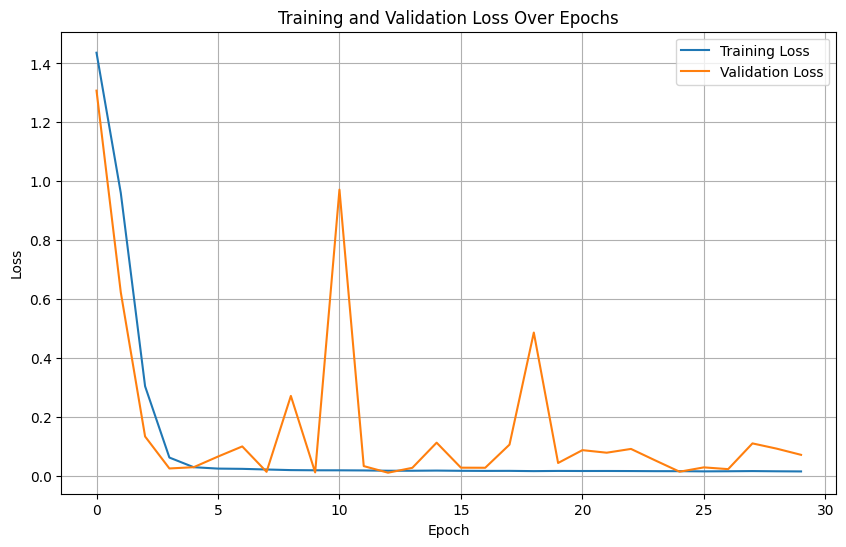

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/', 'vig_patch_model.pth'))
print("Model saved to vig_patch_model.pth in Google Drive.")

Model saved to vig_patch_model.pth in Google Drive.


Image 658×1041 → 83×131 = 10873 patches (patch_size=8×8)

Model parameters: 277,571
Input  (sparse): torch.Size([1, 3, 658, 1041])
Output (recon) : torch.Size([1, 3, 658, 1041])
Observed pixels: 68497 / 684978 (10.0%)
MSE on observed (trained model): 14.2961
MSE on all      (trained model): 142.9490


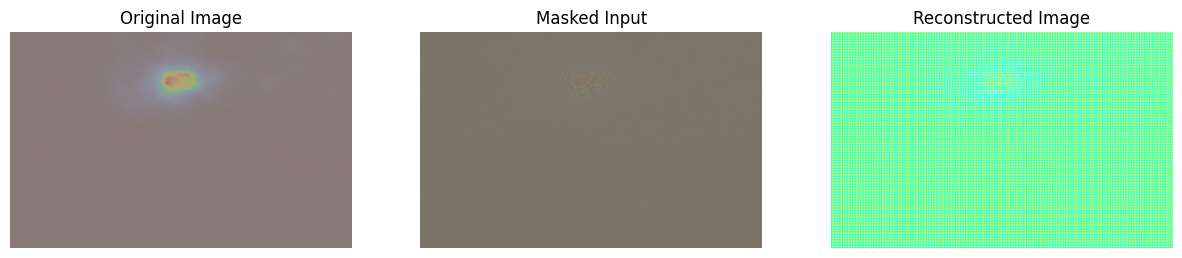

In [ ]:
PATCH_SIZE = 8

img = load_png_as_tensor('/content/drive/MyDrive/dataset_se_split/test/0000007.png', grayscale=False).to(device)
B, C, H, W = img.shape
visualize_patch_grid(H, W, PATCH_SIZE)

mask = generate_sparse_mask(H, W, observed_fraction=0.10, device=device)
sparse_input = apply_mask(img, mask)

model.load_state_dict(torch.load(os.path.join('/content/drive/MyDrive/', 'vig_patch_model.pth')))
model.eval()

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

with torch.no_grad():
    reconstruction = model(sparse_input)

print(f"Input  (sparse): {sparse_input.shape}")
print(f"Output (recon) : {reconstruction.shape}")
print(f"Observed pixels: {mask.sum().item():.0f} / {H*W} "
      f"({100*mask.mean().item():.1f}%)")

loss_obs = F.mse_loss(reconstruction * mask, img * mask)
loss_all = F.mse_loss(reconstruction, img)
print(f"MSE on observed (trained model): {loss_obs.item():.4f}")
print(f"MSE on all      (trained model): {loss_all.item():.4f}")

def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(tensor.device)
    denormalized = tensor * std + mean
    return torch.clamp(denormalized, 0, 1)

plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(denormalize_image(img).squeeze().permute(1, 2, 0).cpu().numpy(), cmap="viridis")
plt.title('Original Image')
plt.axis('off')

# Masked Input
plt.subplot(1, 3, 2)
plt.imshow(denormalize_image(sparse_input).squeeze().permute(1, 2, 0).cpu().numpy(), cmap="viridis")
plt.title('Masked Input')
plt.axis('off')

# Reconstructed Image
plt.subplot(1, 3, 3)
plt.imshow(denormalize_image(reconstruction).squeeze().permute(1, 2, 0).cpu().numpy(), cmap="viridis")
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()